<a href="https://colab.research.google.com/github/masaki-kawa/uts-study-notes/blob/main/data/raw/colab/Deep_Learning_Lab4_Exercise3_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning and Fine-Tuning


---

In this third exercise, we will learn how to apply fine-tuning on a model which is just an extension of transfer learning.

This exercise is split in several parts:
1.   Loading and Exploring Dataset
2.   Preparing Dataset
3.   Defining the Architecture of CNN
4.   Training and Evaluation of the Model
5.   Analysing the Results

# Land Cover Clasification (multi-class classification)

## Dataset

Euro SAT Sentinel-2 dataset is comprised of 27000 images of 10 categories of land use . The full dataset can be found here https://github.com/phelber/eurosat .

## Objective

Our goal is to use a pre-trained Convolution Neural Network model and assess its performance then we will fine-tune it and see the impact.

## Instructions

This is a guided exercise where some of the code have already been pre-defined. Your task is to fill the remaining part of the code (it will be highlighted with placehoders) to train and evaluate your model.

This exercise is split in several parts:
1.   Loading and Exploration of the Dataset
2.   Preparing the Dataset
3.   Load a pre-trained inception_v3 model
4.   Training and Evaluation of the inception_v3 model

## Exercise 3 Solution

### 1. Loading and exploring the Dataset

**[1.1]**
First we need to import the SSL module and disable default certificate verfication

In [ ]:
# Solution
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

**[1.2]** First we need to import the relevant class and libraries from PyTorch including 'os' in python.

In [ ]:
# Solution
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

**[1.3]** Apply transformation using compose class to the image. This time we will not only normalize the images but we will also perform some data transformation such as Resize (image_size, image_size).

In [ ]:
# Solution
image_size = 299
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),                                  # Resize images to a fixed dimension (299x299) required by Inception_v3.
    transforms.ToTensor(),                                                        # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])   # Normalize images
])

https://discuss.pytorch.org/t/discussion-why-normalise-according-to-imagenet-mean-and-std-dev-for-transfer-learning/115670

**[1.4]**
Now need to download locally the zip file from the link provided earlier. The result of this method is the directory where the file has been downloaded.

##### Task: download the dataset locally

In [ ]:
# Solution
data_dir = './'
full_dataset = datasets.EuroSAT(root=data_dir, download = True, transform=transform)

100%|██████████| 94.3M/94.3M [00:01<00:00, 68.6MB/s]


**[1.5]**
Let's load the dataset using torchvision.datasets.ImageFolder [ https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html ].

In [ ]:
# Solution
data_dir = './eurosat/2750'
full_dataset = datasets.ImageFolder(root=data_dir, transform = transform)

### 2.   Preparing the Dataset

**[2.1]**
Lets split the size of the full_dataset into train, test and validation data set according to following ratio 70%:15%:15% and save it into train_ratio, val_ratio and test_ratio.

In [ ]:
# Solution
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

**[2.2]**
According to the size of the dataset, now we will split a dataset into several subsets such as train_set,val_set, and test_set.

In [ ]:
# Solution
# Split indices into training and combined validation/test indices
train_indices, test_val_indices = train_test_split(range(len(full_dataset)), test_size=(val_ratio + test_ratio), random_state=42)

# Split combined validation/test indices into separate validation and test indices
val_indices, test_indices = train_test_split(test_val_indices, test_size=test_ratio/(val_ratio + test_ratio), random_state=42)

train_set = Subset(full_dataset, train_indices)  # Subset for training data
val_set = Subset(full_dataset, val_indices)      # Subset for validation data
test_set = Subset(full_dataset, test_indices)    # Subset for test data


**[2.3]**  Now we will call the DataLoader function that iteratively loads data based on batch size, shuffle and save it into three different variables called `train_loader`, `val_loader` and `test_loader`. Set the `BATCH_SIZE` to 20. The shuffle is a boolean variable. By default the shuffle value is false. If the shuffle is `True` means that the data is randomly shuffled before each epoch, so the order of the data is different in each epoch. (https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)

In [ ]:
# Solution
batch_size = 20
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

**[2.4]**  Let's have a look at the length of `train_set`, `val_set`, and `test_set`.

In [ ]:
# Print sizes of datasets
print("Training set size:", len(train_set))
print("Validation set size:", len(val_set))
print("Test set size:", len(test_set))

Training set size: 18900
Validation set size: 4050
Test set size: 4050


**[2.5]** Let's print the class labels of the dataset.

In [ ]:
# Solution
class_labels = full_dataset.classes   # Get the class labels

# Print the class labels
print("Class labels:", class_labels)
print(f"Total number of classes: {len(class_labels)}")

Class labels: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total number of classes: 10


**[2.6]** Now we will display the images with the labels.

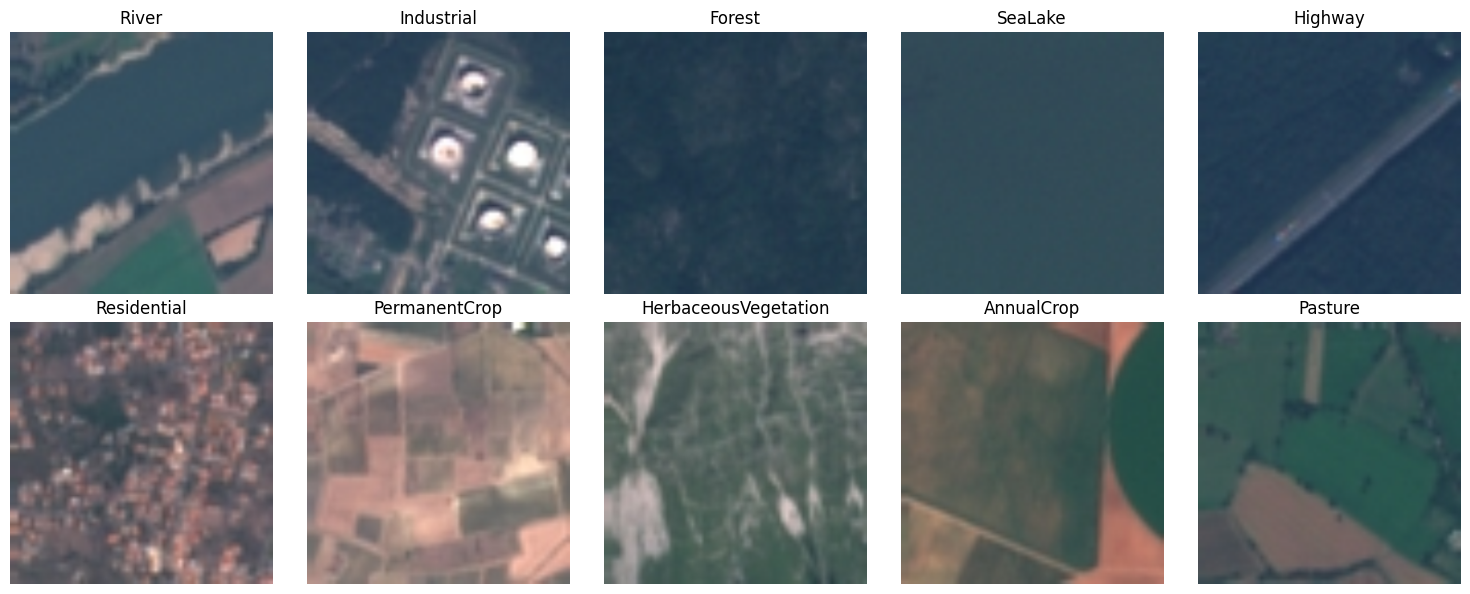

In [ ]:
# Solution
import matplotlib.pyplot as plt
import numpy as np

# Function to display images in a grid along with their class labels.
def show_images(images, labels, class_labels):

    # Calculate the number of images and rows required
    num_images = len(images)
    num_rows = (num_images + 4) // 5    # Arrange 5 images per row

    # Create a figure and axes for subplots
    fig, axes = plt.subplots(num_rows, 5, figsize=(15, 3 * num_rows))
    axes = axes.flatten()               # Flatten axes array for easier iteration

    # Loop through the images and corresponding labels
    for i, (image, label) in enumerate(zip(images, labels)):

        image = image.numpy().transpose((1, 2, 0))      # Convert from tensor to NumPy array and change the channel dimension
        mean = np.array([0.485, 0.456, 0.406])          # Mean values used for normalization
        std = np.array([0.229, 0.224, 0.225])           # Standard deviation values used for normalization
        image = std * image + mean                      # Denormalize the image
        image = np.clip(image, 0, 1)                    # Clip pixel values to range [0, 1]

        # Display the image and set its title as the class label
        axes[i].imshow(image)                   # Display the image
        axes[i].set_title(class_labels[label])  # Set the title of the subplot as the class label
        axes[i].axis('off')                     # Hide axis

    # Hide empty subplots
    for j in range(num_images, num_rows * 5):
        axes[j].axis('off')  # Hide axis for empty subplots

    # Adjust layout and display the plot
    plt.tight_layout()      # Adjust the layout of subplots
    plt.show()              # Display the plot

# Get one image from each class
images, labels = [], []                   # Initialize lists to store images and labels
classes_found = set()                     # Keep track of classes already found
for img, lbl in train_loader:             # Iterate through the training loader
    for image, label in zip(img, lbl):    # Iterate through each image and label in the batch

        # Check if we have already found an image from this class
        if class_labels[label.item()] not in classes_found:
            images.append(image)                                # Add the image to the list of images
            labels.append(label)                                # Add the label to the list of labels
            classes_found.add(class_labels[label.item()])       # Add the class to the set of found classes

    # If we have found one image from each class, stop looping
    if len(images) == len(class_labels):
        break

# Display one image from each class with 5 images per row
show_images(images, labels, class_labels)         # Call the show_images function to display the images

### 3.   Defining the Architecture of CNN

**[3.1]** Create a variable called `device` that will automatically select a GPU if available. Otherwise it will default to CPU.

In [ ]:
# Solution
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**[3.2]** Now we will initialize the inception_v3 model by specifying the parameter `pretrained = True`, i.e. loading the pre-trained model (https://pytorch.org/vision/0.12/generated/torchvision.models.inception_v3.html#torchvision.models.inception_v3).

In [ ]:
# Solution
# Initialize the pre-trained Inception_v3 model with pretrained weights.
base_model = models.inception_v3(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 196MB/s] 


**[3.3]** Let's freeze the part of the model by setting the value of `requires_grad` as `false`, i.e. no changes happen to its parameters. (https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad.html#torch.Tensor.requires_grad)

In [ ]:
# Solution
# Freeze all layers
for param in base_model.parameters():
    param.requires_grad = False

**[3.4]** As you can see, we have now a inception_v3 model with no parameters update and top layers used for making the predictions. We will add 2 fully connected layers to the inception_v3.

##### Task: Create a new model by combining the inception_v3 model to 2 fully connnected layers (the first one will have 500 units).For the last layer. We are using `softmax` activation function. it is used for multiclass classification.

`Softmax Resource`: https://www.analyticsvidhya.com/blog/2021/04/introduction-to-softmax-for-neural-network/

In [ ]:
# Solution
num_ftrs = base_model.fc.in_features
base_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 500),  # Change the number of units in the first fully connected layer
    nn.ReLU(),
    nn.Linear(500, 10),        # Output layer with 10 units for 10 output classes
    nn.Softmax(dim=1)          # Softmax activation for classification
)
tuned_model = base_model

**[3.6]** After modifying the last layer of inception_v3, let's have a look at the modified inception_v3 architecture

##### Task: Print the summary of newly modified inception_v3 model

In [ ]:
# Solution
print(tuned_model)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

### 4. Training and Evaluation of the Model

**[4.1]**  Instantiate a `nn.CrossEntropyLoss()` and save it into a variable called `criterion`. After then Instantiate a `torch.optim.Adam()` optimizer with the model's parameters and 0.00001 as learning rate and save it into a variable called `optimizer`.

In [ ]:
# Solution
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tuned_model.parameters(), lr=0.00001)

**[4.2]**  Let's introduce a custom class called `Customcallback` to control the behaviours of the training. This class offers the following functionalities:


*   Monitor the training
*   Adjusting learning rates
*   Early stopping






In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class CustomCallback:
    def __init__(self, early_stop_patience=5, reduce_lr_factor=0.2, reduce_lr_patience=3, reduce_lr_min_lr=0.0000001, checkpoint_path='checkpoint.pth', log_dir='logs'):

        # Parameters for early stopping and learning rate reduction
        self.early_stop_patience = early_stop_patience    # Patience for early stopping
        self.reduce_lr_factor = reduce_lr_factor          # Factor by which to reduce learning rate
        self.reduce_lr_patience = reduce_lr_patience      # Patience for reducing learning rate
        self.reduce_lr_min_lr = reduce_lr_min_lr          # Minimum learning rate
        self.checkpoint_path = checkpoint_path            # Path to save model checkpoints
        # self.log_dir = log_dir  # Directory for logging (if needed)

        self.early_stop_counter = 0                       # Counter to track epochs without improvement
        self.best_val_loss = float('inf')                 # Best validation loss

        self.optimizer = None                             # Placeholder for the optimizer
        self.scheduler = None                             # Placeholder for the LR scheduler

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer                        # Set optimizer for training

    def on_epoch_end(self, epoch, val_loss):
        # Early Stopping: Check if the validation loss improved
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.early_stop_counter = 0                   # Reset counter if improvement is seen
        else:
            self.early_stop_counter += 1                  # Increment counter if no improvement

        # Trigger early stopping if no improvement for a defined number of epochs
        if self.early_stop_counter >= self.early_stop_patience:
            print("Early stopping triggered!")
            return True                                   #  Return True to signal stopping training

        # Adjust the learning rate if a plateau in validation loss is detected
        if self.scheduler is not None:
            self.scheduler.step(val_loss)                 # Adjust learning rate based on validation loss

        return False  # Continue training if conditions are not met

    def on_train_begin(self):
        # Initialize the ReduceLROnPlateau scheduler with the optimizer and parameters.
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=self.reduce_lr_factor,patience=self.reduce_lr_patience, min_lr=self.reduce_lr_min_lr)

    def on_train_end(self):
        pass                  # Additional cleanup can be done here if needed

    def set_model(self, model):
        self.model = model    # Store the model reference

**[4.3]**  Instantiate a `CustomCallback()` and save it into a variable called `custom_callback`.

In [ ]:
# Solution
custom_callback = CustomCallback()

**[4.3]**  Set the `optimizer` for the `custom_callback`.

In [ ]:
# Solution
custom_callback.set_optimizer(optimizer)

**[4.4]**  Move `tuned_model` to device.

In [ ]:
# Solution
tuned_model.to(device)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

**[4.5]**  Pass the `tuned_model` as a parameter of the function `set_model` of `custom_callback` class.

In [ ]:
# Solution
# Set the model for the custom callback
custom_callback.set_model(tuned_model)

**[4.6]**  Set up a learning rate scheduler for `ReduceLROnPlateau` for reducing the learning rate when a metric has stopped improving (https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)

In [ ]:
#Create a learning rate scheduler for reducing LR on plateau based on validation loss.
lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, min_lr=1e-6)

**[4.7]** **Training:** Now it is time to train our model. Set the `EPOCHS` to 10 and create a for loop that will iterate based on the EPOCHS value. A nested loop is initiated that extracts images and labels from `train_loader` and introduce the following logics:
- reset the gradients (https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- perform back propagation
- update the weights
- Count the total loss

To validate the model a nested loop is initiated that extracts images and labels from `val_loader` and introduce the following logics:
- disable computing gradients (https://pytorch.org/docs/stable/generated/torch.no_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- Count the total loss
- Count the correct outcome

In [ ]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    tuned_model.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer.zero_grad()                                   # Reset gradients to zero
        outputs = tuned_model(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

    # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    # Validation
    tuned_model.eval()              # Set the model to evaluation mode
    running_val_loss = 0.0          # Accumulate validation loss
    correct_val = 0                 # Count correct predictions in validation
    total_val = 0                   # Total validation samples processed

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
            outputs = tuned_model(inputs)                           # Forward pass
            if isinstance(outputs, tuple):
                logits = outputs[0]                                 # Unpack logits if model returns tuple
            else:
                logits = outputs
            loss = criterion(logits, labels)                        # Calculate loss

            running_val_loss += loss.item() * inputs.size(0)        # Accumulate validation loss
            _, predicted = torch.max(logits, 1)                     # Get predicted labels
            total_val += labels.size(0)                             # Increment total validation samples
            correct_val += (predicted == labels).sum().item()       # Increment correctly predicted validation samples

    # Compute average validation loss and accuracy for the epoch.
    epoch_val_loss = running_val_loss / len(val_loader.dataset)     # Average validation loss
    val_accuracy = correct_val / total_val                          # Validation accuracy

    # Append values to lists
    train_losses.append(epoch_train_loss)                           # Append training loss
    train_accuracies.append(train_accuracy)                         # Append training accuracy
    val_losses.append(epoch_val_loss)                               # Append validation loss
    val_accuracies.append(val_accuracy)                             # Append validation accuracy

    # Update learning rate scheduler based on validation loss.
    lr_scheduler.step(epoch_val_loss)                               # Adjust learning rate based on validation loss

    # Check for early stopping using the custom callback.
    if custom_callback.on_epoch_end(epoch, epoch_val_loss):
        break                                                       # Stop training if early stopping criterion is met

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 2.2145, Train Accuracy: 0.3684, Val Loss: 2.0476, Val Accuracy: 0.5788
Epoch [2/10], Train Loss: 1.9946, Train Accuracy: 0.5735, Val Loss: 1.9250, Val Accuracy: 0.6042
Epoch [3/10], Train Loss: 1.9298, Train Accuracy: 0.5859, Val Loss: 1.8929, Val Accuracy: 0.6069
Epoch [4/10], Train Loss: 1.8958, Train Accuracy: 0.6194, Val Loss: 1.8488, Val Accuracy: 0.6714
Epoch [5/10], Train Loss: 1.8678, Train Accuracy: 0.6455, Val Loss: 1.8251, Val Accuracy: 0.6788
Epoch [6/10], Train Loss: 1.8475, Train Accuracy: 0.6549, Val Loss: 1.8111, Val Accuracy: 0.6852
Epoch [7/10], Train Loss: 1.8387, Train Accuracy: 0.6581, Val Loss: 1.7986, Val Accuracy: 0.6867
Epoch [8/10], Train Loss: 1.8222, Train Accuracy: 0.6790, Val Loss: 1.7740, Val Accuracy: 0.7323
Epoch [9/10], Train Loss: 1.8077, Train Accuracy: 0.7003, Val Loss: 1.7598, Val Accuracy: 0.7420
Epoch [10/10], Train Loss: 1.7919, Train Accuracy: 0.7112, Val Loss: 1.7507, Val Accuracy: 0.7467


**[4.8]** **Testing:** Now it is time to test our model. Initiate the `tuned_model.eval()` along with `torch.no_grad()` to turn off the gradients. Finally calculate the total and correct value.

In [ ]:
# Set the model to evaluation mode and disable gradients for testing.
tuned_model.eval()
test_correct = 0          # Counter for correct predictions in testing
test_total = 0            # Total test samples processed
test_running_loss = 0.0   # Accumulator for test loss

with torch.no_grad():                                           # Turn off gradients during evaluation
    for inputs, labels in test_loader:                          # Iterate through test data
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU
        outputs = tuned_model(inputs)                           # Get model predictions

        if isinstance(outputs, tuple):
            logits = outputs[0]                                 # Unpack logits from model outputs if necessary
        else:
            logits = outputs
        loss = criterion(logits, labels)                        # Calculate loss

        test_running_loss += loss.item() * inputs.size(0)       # Update running test loss
        _, predicted = torch.max(logits, 1)                     # Get predicted labels
        test_total += labels.size(0)                            # Update total number of samples
        test_correct += (predicted == labels).sum().item()      # Update number of correctly predicted samples

# Calculate test loss and accuracy
test_loss = test_running_loss / len(test_loader.dataset)  # Average test loss
test_accuracy = test_correct / test_total                 # Test accuracy

# Print test results
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 1.7416, Test Accuracy: 0.7541


### 5. Analysing the Results

**[5.1]** Let's plot the training and validation Accuracies

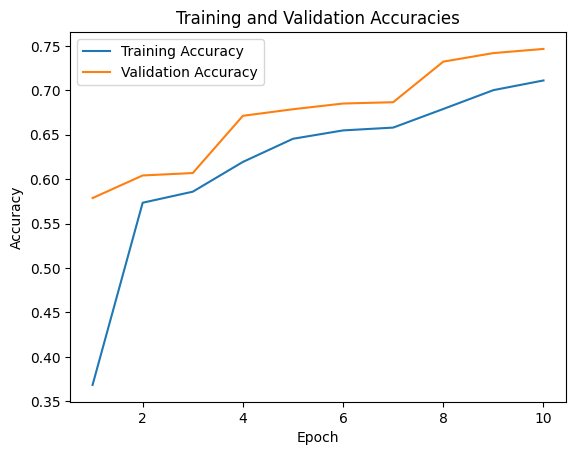

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation losses starting from index 1
epochs = range(1, len(train_losses) + 1)  # Generate the range of epochs starting from 1

# Plot training and validation accuracies
plt.plot(epochs, train_accuracies, label='Training Accuracy')   # Plot training accuracies over epochs
plt.plot(epochs, val_accuracies, label='Validation Accuracy')   # Plot validation accuracies over epochs
plt.xlabel('Epoch')                                             # Set label for the x-axis
plt.ylabel('Accuracy')                                          # Set label for the y-axis
plt.title('Training and Validation Accuracies')                 # Set title for the plot
plt.legend()                                                    # Display legend
plt.show()                                                      # Show the plot

**[5.2]** Let's plot the training and validation losses

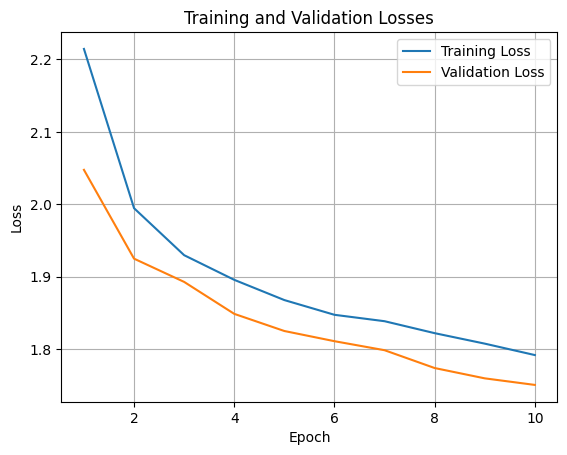

In [ ]:
# Plot training and validation losses starting from index 1
epochs = range(1, len(train_losses) + 1)  # Generate the range of epochs starting from 1

# Plot training and validation losses
plt.plot(epochs, train_losses, label='Training Loss')   # Plot training losses over epochs
plt.plot(epochs, val_losses, label='Validation Loss')   # Plot validation losses over epochs
plt.xlabel('Epoch')                                     # Set label for the x-axis
plt.ylabel('Loss')                                      # Set label for the y-axis
plt.title('Training and Validation Losses')             # Set title for the plot
plt.legend()                                            # Display legend
plt.grid(True)                                          # Display grid
plt.show()                                              # Show the plot